# Applied Data Science - Exercise 3

This is the third of fifth exercises in the course T-786-APDS Applied Data Science at Reykjavik University.

## Preparation

Please refer to chapters 3, 5, 6 and 7 of the textbook for the lab. Also skim over chapter 4 and make sure you are familiar with the theory.


## Task

This exercise continues from where the previous exercise left off. Having explored the car listings dataset and prepared it for machine learning algorithms, you will now train regression models in order to predict the listed car price.

You will also train classification models on the MSRP dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

In [3]:
# Check python version.
# This code should run for python version >=3.6

print("python", sys.version)

python 3.12.1 (main, Dec 12 2023, 14:10:04) [Clang 13.0.0 (clang-1300.0.29.30)]


## Creating the training and test sets

We repeat the steps from the first exercise to split the data into training and test sets, making sure that we use the same `random_state` as before.

In [4]:
vehicles = pd.read_csv("../Ass1/vehicles.csv", index_col=0)

In [5]:
reduced_df = vehicles.copy()
reduced_df = reduced_df[reduced_df['price'] > 0]
reduced_df = reduced_df[reduced_df['price'].notna()]
reduced_df = reduced_df[reduced_df['price'] < 1000000]
reduced_df = reduced_df[~((reduced_df.manufacturer.isnull()) & (reduced_df.manufacturer.isnull()))]
reduced_df = reduced_df.drop(columns=[
    'county', 
    'id', 
    'region_url', 
    'url', 
    'image_url',
    'VIN'
])

In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(reduced_df, test_size=0.1, random_state=123)

In [7]:
def preprocess(df_in):
    
    df = df_in.copy()
    
    N = 50
    topN_models = df.model.value_counts().head(N).index.to_numpy()
    df.loc[~df['model'].isin(topN_models),'model'] = 'unknown'
    top_models = list(train_set.model.unique())
    
    df = df.drop(columns=[
        'size', 
        'drive', 
        'lat', 
        'long', 
        'posting_date', 
        'paint_color', 
        'description',
        'state',
        'region'
    ])
    
    df.loc[~df['model'].isin(top_models),'model'] = 'unknown'
    
    df = df.dropna(subset=['year', 'odometer','manufacturer'])
    df['type'].fillna('unknown',inplace=True)
    df['title_status'].fillna('clean', inplace=True)
    df['fuel'].fillna('gas', inplace=True)
    df['cylinders'].fillna('unknown', inplace=True)
    df['transmission'].fillna('automatic', inplace=True)
    df['condition'].fillna('good', inplace=True)
    
    
    X = df.drop('price', axis=1)
    y = df['price'].copy()
    
    return(X,y)

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X, y = preprocess(train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))


pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)

/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_21630/3941203363.py:25: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['type'].fillna('unknown',inplace=True)
/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_21630/3941203363.py:26: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series t

## Regression models

**Task:** Train a linear regression model on the data and print the resulting mean squared error, root mean squared error, mean absolute error and mean absolute percentage error.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

lrmodel = LinearRegression()
lrmodel.fit(X_prepared, y)

y_pred = lrmodel.predict(X_prepared)

mse = mean_squared_error(y, y_pred)
print('MSE:', mse)

rmse = np.sqrt(mse)
print('RMSE:', rmse)

mae = mean_absolute_error(y, y_pred)
print('MAE:', mae)

mape = mean_absolute_percentage_error(y, y_pred)
print('MAPE:', mape)

MSE: 136765949.83086562
RMSE: 11694.697509164811
MAE: 7575.577022145029
MAPE: 90.49611461918272


**Task:** Train a `sklearn.tree.DecisionTreeRegressor` model. First train it on the full training set and then try 3-fold cross validation.

In [ ]:
dtrmodel = DecisionTreeRegressor()
dtrmodel.fit(X_prepared, y)

y_pred = dtrmodel.predict(X_prepared)

mse = mean_squared_error(y, y_pred)
print('MSE:', mse)

rmse = np.sqrt(mse)
print('RMSE:', rmse)

mae = mean_absolute_error(y, y_pred)
print('MAE:', mae)

mape = mean_absolute_percentage_error(y, y_pred)
print('MAPE:', mape)


cross_val = cross_val_score(dtrmodel, X_prepared, y, cv=3, scoring='neg_mean_squared_error')
#Need to do negative scoring, since cross_val considers higher to be better, but we look at a lower score as better
rmse_scores = np.sqrt(-cross_val) #Flip it back to positive
print("Mean RMSE:", rmse_scores.mean())

MSE: 1051922.862548965
RMSE: 1025.6329082810112
MAE: 55.616697040064146
MAPE: 7.353525906313095
Mean RMSE: 8196.141985339988


**Question:** How does the error compare when training with/without cross validation?

**Answer:** `The error appears much lower without cross validation, but this is likely due to overfitting, since the model is being evaluated on the same data it trained on. The cross validation error is a more realistic estimate of performance on unseen data.`

**Task:** Now train a `sklearn.ensemble.RandomForestRegressor` with 3-fold cross validation. Try to find a good combination of hyperparameters by manually changing the `n_estimators` and `max_features` arguments.

In [23]:
from sklearn.ensemble import RandomForestRegressor

rfrmodel = RandomForestRegressor(n_estimators=15, max_features=50)

cross_val = cross_val_score(rfrmodel, X_prepared, y, cv=3, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cross_val)
print("Mean RMSE:", rmse_scores.mean())

Mean RMSE: 6677.097420150084


**Question:** What was the best combination of hyperparameters you found and what was the error?

**Answer:** `The best combination found was n_estimators = 15, and max_features = 50 which resulted in a mean RMSE of 6607. This was the best combination possible without the runtime getting too long`

**Task:** Train a `RandomForestRegressor` model, this time using `sklearn.model_selection.GridSearchCV` to find a good combination of the hyperparameters `n_estimators` and `max_features`.

How long does the `GridSearchCV` take? 

*Hint*: You can use the `time` python module to record the time taken.

In [26]:
from sklearn.model_selection import GridSearchCV
import time

grid_param = {
    'n_estimators': [2, 5, 10],
    'max_features': [10, 50, 100]
}

grid_search = GridSearchCV(RandomForestRegressor(), grid_param, cv=3, scoring='neg_mean_squared_error')

start = time.time()
grid_search.fit(X_prepared, y)
end = time.time()
print("Time taken:", end - start, "seconds")

print("Best params:", grid_search.best_params_)
print("Best RMSE:", np.sqrt(-grid_search.best_score_))

Time taken: 1497.4477560520172 seconds
Best params: {'max_features': 50, 'n_estimators': 10}
Best RMSE: 6708.987405041346


**Question:** What was the best combination of hyperparameters you found using `GridSearchCV`and what was the error?

**Answer:** `The best combination was max_features = 50 and n_estimators = 10. The RMSE was 6708. This took almost 25 minutes to run`

**Task:** Again, look for good hyperparameters for training a `RandomForestRegressor` model, but this time using `sklearn.model_selection.RandomSearchCV`.

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param = {
    'n_estimators': [2, 4, 6, 8],
    'max_features': [10, 30, 50, 70, 100]
}

random_search = RandomizedSearchCV(RandomForestRegressor(), param, n_iter=5, cv=3, scoring='neg_mean_squared_error')

random_search.fit(X_prepared, y)

print("Best params:", random_search.best_params_)
print("Best RMSE:", np.sqrt(-random_search.best_score_))

Best params: {'n_estimators': 6, 'max_features': 100}
Best RMSE: 6950.754405347754


**Task:** Now try other regression models, including Polynomial Regression and SVM regression with different kernel types. Make sure you use cross validation and look for good hyperparameters.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

'''

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

cross_val = cross_val_score(poly_model, X_prepared, y, cv=3, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cross_val)
print("Mean RMSE:", rmse_scores.mean())

'''
#Run time is too long

In [ ]:
from sklearn.svm import SVR

'''

svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1) # kernel: type of curve fitted, C: penalty for errors, epsilon: acceptable error margin

cross_val = cross_val_score(svm_model, X_prepared, y, cv=3, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cross_val)
print("Mean RMSE:", rmse_scores.mean())

'''
#Run time is too long

**Question:** What models did you try and what was the best hyperparameter combination for the best model? Did you get a decrease in validation error?

**Answer:** `An attempt was made to try both polynomial regression and SVM regression, but the run time was simply way too long for such a large dataset. The best model ended up being the Random forest regression, which got a mean RMSE of 6607, with hyperparameters n_estimators=15, max_features=50`

**Task:** Retrain your best model on the full training set. What is the resulting mean squared error, root mean squared error, mean absolute error and mean absolute percentage error?

In [28]:
rfrmodel = RandomForestRegressor(n_estimators=15, max_features=50)
rfrmodel.fit(X_prepared, y)

y_pred = rfrmodel.predict(X_prepared)

mse = mean_squared_error(y, y_pred)
print('MSE:', mse)

rmse = np.sqrt(mse)
print('RMSE:', rmse)

mae = mean_absolute_error(y, y_pred)
print('MAE:', mae)

mape = mean_absolute_percentage_error(y, y_pred)
print('MAPE:', mape)

MSE: 7687909.872151008
RMSE: 2772.708039471702
MAE: 904.3798025952639
MAPE: 16.528255728094976


In the upcoming lectures, you will learn about some more modeling techniques, including Deep Learning. We will be trying those techniques on our dataset as well, so we are not yet done with this training data. Thus, we will not evaluate our best model on the test data at this stage.

## Classification

Luxury cars probably have a different price distribution to other car categories. Can we distinguish between luxury cars and non-luxury cars without knowing the car's model, make and price?

We will now try classifying cars in the MSRP dataset into luxury and non-luxury categories. We will imagine that we do not have the  `model`, `make`, `msrp` and `popularity` attributes and see how accurately we can spot luxury cars.

Since the cars in the MSRP dataset are often assigned multiple market categories, we need to decide how to create a binary luxury/non-luxury variable. We will assume that the car is a luxury vehicle if one of the listed categories is `Luxury`.

In [31]:
msrp_df = pd.read_csv("../Ass2/data.csv")

In [32]:
for col in msrp_df.columns:
    new_col = '_'.join(col.lower().split(' '))
    msrp_df.rename({col: new_col}, inplace=True, axis=1)

In [33]:
msrp_df['is_luxury'] = msrp_df.market_category.str.contains('Luxury')

In [34]:
msrp_df = msrp_df.drop(columns=['model','market_category', 'make', 'msrp', 'popularity'])

In [35]:
msrp_train_set, msrp_test_set = train_test_split(
    msrp_df.dropna(subset=['is_luxury']), 
    test_size=0.1, 
    random_state=123)
msrp_train_df = msrp_train_set.copy()

**Task:** Make sure you understand what the above code is doing and verify that `msrp_train_df` has the features we need.

In [43]:
msrp_train_df.head()

,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,is_luxury
228,2017,regular unleaded,300.0,6.0,AUTOMATIC,all wheel drive,4.0,Large,Sedan,27,18,False
462,2002,premium unleaded (required),442.0,12.0,AUTOMATIC,rear wheel drive,2.0,Compact,Coupe,14,9,False
7356,2015,regular unleaded,148.0,4.0,AUTOMATIC,front wheel drive,4.0,Compact,4dr SUV,32,25,False
3920,2015,regular unleaded,288.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr SUV,22,16,False
8117,1992,regular unleaded,116.0,4.0,MANUAL,four wheel drive,2.0,Compact,Regular Cab Pickup,20,17,False


In [44]:
msrp_train_df.info()

<class 'pandas.DataFrame'>
Index: 10722 entries, 228 to 3582
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               10722 non-null  int64  
 1   engine_fuel_type   10720 non-null  str    
 2   engine_hp          10666 non-null  float64
 3   engine_cylinders   10698 non-null  float64
 4   transmission_type  10722 non-null  str    
 5   driven_wheels      10722 non-null  str    
 6   number_of_doors    10716 non-null  float64
 7   vehicle_size       10722 non-null  str    
 8   vehicle_style      10722 non-null  str    
 9   highway_mpg        10722 non-null  int64  
 10  city_mpg           10722 non-null  int64  
 11  is_luxury          10722 non-null  bool   
dtypes: bool(1), float64(3), int64(3), str(5)
memory usage: 1015.7 KB


In [46]:
N = len(msrp_train_df.index)
msrp_train_df.isnull().sum()/N

year                 0.000000
engine_fuel_type     0.000187
engine_hp            0.005223
engine_cylinders     0.002238
transmission_type    0.000000
driven_wheels        0.000000
number_of_doors      0.000560
vehicle_size         0.000000
vehicle_style        0.000000
highway_mpg          0.000000
city_mpg             0.000000
is_luxury            0.000000
dtype: float64

In [45]:
msrp_train_df.engine_fuel_type.value_counts()

engine_fuel_type
regular unleaded                                6459
premium unleaded (required)                     1803
premium unleaded (recommended)                  1379
flex-fuel (unleaded/E85)                         807
diesel                                           137
electric                                          56
flex-fuel (premium unleaded required/E85)         49
flex-fuel (premium unleaded recommended/E85)      22
flex-fuel (unleaded/natural gas)                   6
natural gas                                        2
Name: count, dtype: int64

**Task:** Get familiar with the training data, assuming now that `is_luxury` is our target variable.

**Task:** Prepare the MSRP training data for machine learning algorithms, treating `is_luxury` as the target variable.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def preprocess_msrp(df_in):

    df = df_in.copy()

    df = df.dropna(subset=['engine_hp', 'engine_cylinders', 'number_of_doors'])

    df['engine_fuel_type'] = df['engine_fuel_type'].fillna('regular_unleaded')

    X = df.drop('is_luxury', axis=1)
    y = df['is_luxury'].copy()
    
    return(X,y)

X, y = preprocess_msrp(msrp_train_set)

num_attribs = list(X.select_dtypes('number'))
cat_attribs = list(X.select_dtypes('object'))

pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attribs),
    ('cat', OneHotEncoder(), cat_attribs)
])

X_prepared = pipeline.fit_transform(X)

    

/var/folders/7v/25vl4fsd1jv9jsr72bhy8wkw0000gn/T/ipykernel_21630/2867180872.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_attribs = list(X.select_dtypes('object'))


**Task:** Train binary classification models on the MSRP training data. Try different models, including Logistic Regression, Decision Tree, Random Forest, Stochastic Gradient Descent classifier and SVM. For each classifier, look at the accuracy, confusion matrix, precision, recall and F$_1$ score. When applicable, plot precision-recall curves for different thresholds and calculate the area under the curve.

Accuracy: 0.8498261441593835
Confusion matrix: [[7075  587]
 [1011 1968]]
Precision score: 0.7702544031311155
Recall score: 0.6606243705941591
F1 score: 0.7112396096855801


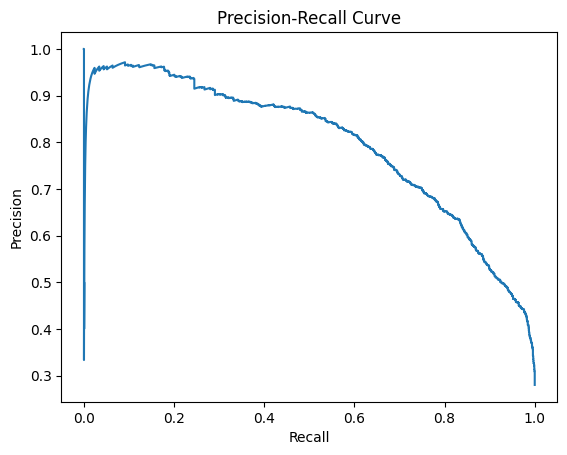

AUC: 0.7962692213944991


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_prepared, y)
y_pred = log_model.predict(X_prepared)

accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y, y_pred)
print('F1 score:', f1)

from sklearn.metrics import precision_recall_curve, auc

y_scores = log_model.predict_proba(X_prepared)[:, 1] #Predict prob instead of true/false
precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

auc_score = auc(recall, precision)
print('AUC:', auc_score)


Accuracy: 0.9968048115778593
Confusion matrix: [[7651   11]
 [  23 2956]]
Precision score: 0.9962925513987192
Recall score: 0.9922792883517959
F1 score: 0.9942818701648167


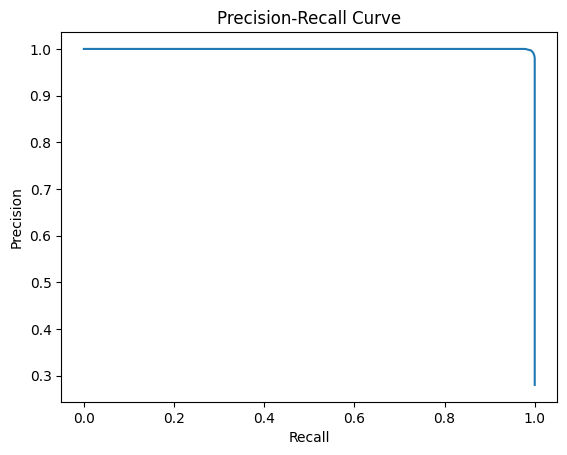

AUC: 0.9999081833465874


In [51]:
from sklearn.tree import DecisionTreeClassifier

dtcmodel = DecisionTreeClassifier()
dtcmodel.fit(X_prepared, y)
y_pred = dtcmodel.predict(X_prepared)

accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y, y_pred)
print('F1 score:', f1)


y_scores = dtcmodel.predict_proba(X_prepared)[:, 1] #Predict prob instead of true/false
precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

auc_score = auc(recall, precision)
print('AUC:', auc_score)

This looks way too good. Seems to be overfitted, similar to the Decision tree regressor

Accuracy: 0.9968048115778593
Confusion matrix: [[7644   18]
 [  16 2963]]
Precision score: 0.9939617577993962
Recall score: 0.994629070157771
F1 score: 0.9942953020134229


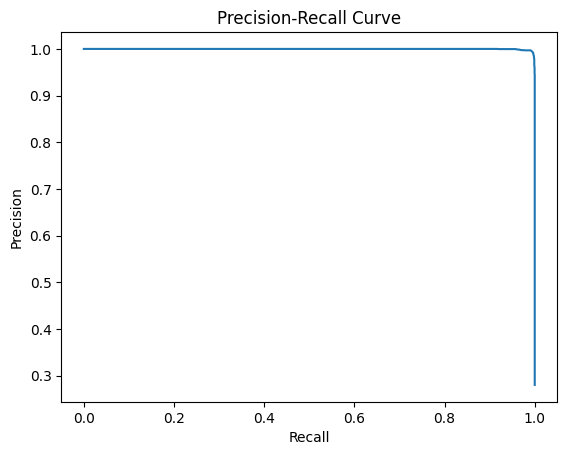

AUC: 0.9997981306883775


In [52]:
from sklearn.ensemble import RandomForestClassifier

rfcmodel = RandomForestClassifier()
rfcmodel.fit(X_prepared, y)
y_pred = rfcmodel.predict(X_prepared)

accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y, y_pred)
print('F1 score:', f1)


y_scores = rfcmodel.predict_proba(X_prepared)[:, 1] #Predict prob instead of true/false
precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

auc_score = auc(recall, precision)
print('AUC:', auc_score)

Again, seems to be overfitted, results are way too good.

Accuracy: 0.851047833850202
Confusion matrix: [[7238  424]
 [1161 1818]]
Precision score: 0.8108831400535237
Recall score: 0.6102719033232629
F1 score: 0.6964183106684543


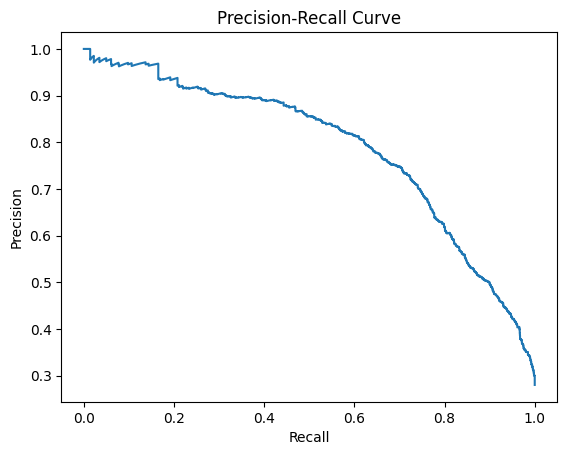

AUC: 0.7885502211327046


In [53]:
from sklearn.linear_model import SGDClassifier

sgdmodel = SGDClassifier()
sgdmodel.fit(X_prepared, y)
y_pred = sgdmodel.predict(X_prepared)

accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y, y_pred)
print('F1 score:', f1)


y_scores = sgdmodel.decision_function(X_prepared) #SGD classifier doesnt support the prob prediction. replace with decision_function which gives a confidence score
precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

auc_score = auc(recall, precision)
print('AUC:', auc_score)

Results seem much more realistic

Accuracy: 0.9196504087961658
Confusion matrix: [[7405  257]
 [ 598 2381]]
Precision score: 0.9025777103866566
Recall score: 0.7992614971466935
F1 score: 0.8477835143314937


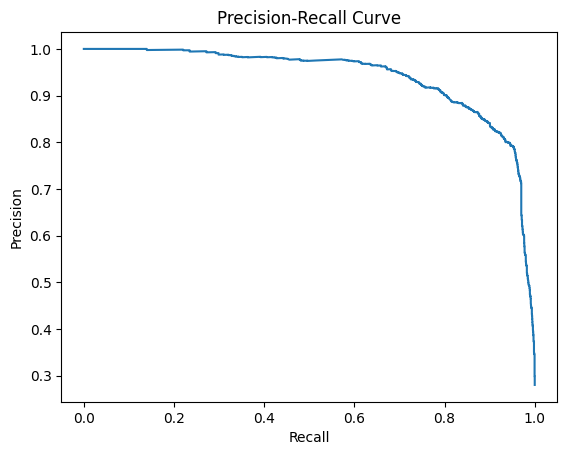

AUC: 0.9404987569652148


In [54]:
from sklearn.svm import SVC

svcmodel = SVC(probability=True)
svcmodel.fit(X_prepared, y)
y_pred = svcmodel.predict(X_prepared)

accuracy = accuracy_score(y, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y, y_pred)
print('F1 score:', f1)


y_scores = svcmodel.predict_proba(X_prepared)[:, 1] #Predict prob instead of true/false
precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

auc_score = auc(recall, precision)
print('AUC:', auc_score)

**Question:** What was the best model you found?

**Answer:** `Out of all the models, both tree models gave us the best results, but this appears to be due to overfitting. Besides those, SVM gave the best results`

**Task:** Validate your best model on the MSRP test data. How does it perform?

In [55]:
X_test, y_test = preprocess_msrp(msrp_test_set)

X_test_prepared = pipeline.transform(X_test)

y_pred = svcmodel.predict(X_test_prepared)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion matrix:', conf_matrix)

prec_score = precision_score(y_test, y_pred)
print('Precision score:', prec_score)

rec_score = recall_score(y_test, y_pred)
print('Recall score:', rec_score)

f1 = f1_score(y_test, y_pred)
print('F1 score:', f1)

Accuracy: 0.909710391822828
Confusion matrix: [[834  40]
 [ 66 234]]
Precision score: 0.8540145985401459
Recall score: 0.78
F1 score: 0.8153310104529616


Accuracy: 0.909710391822828
Confusion matrix: [[834  40]
                   [ 66 234]]
Precision score: 0.8540145985401459
Recall score: 0.78
F1 score: 0.8153310104529616

Seems to perform pretty well!